Esta sección de Aurélien Géron cierra el bloque conceptual de los árboles de decisión abordando dos pilares: la **eficiencia computacional** (por qué son tan rápidos al predecir pero costosos de entrenar) y el dilema matemático entre medir la pureza con **Gini** o con **Entropía**.



A continuación, encontrarás la traducción técnica adaptada, las correcciones de notación matemática y los scripts de Python para medir tiempos de ejecución y comparar ambas métricas.

---



## 1. Traducción, Corrección y Actualización del Texto



# Complejidad Computacional



Hacer predicciones requiere recorrer el árbol de decisión desde la raíz hasta una hoja. 

Los árboles de decisión generalmente están aproximadamente equilibrados, por lo que recorrerlos requiere pasar por aproximadamente $O(\log_2(m))$ nodos, donde $m$ es el número de instancias de entrenamiento y $\log_2(m)$ es el logaritmo binario de $m$ (igual a $\frac{\log(m)}{\log(2)}$).



Dado que en cada nodo solo se requiere verificar el valor de una sola característica, la complejidad general de la predicción es $O(\log_2(m))$, **independientemente del número de características**. 

Por lo tanto, las predicciones son extremadamente rápidas, incluso cuando se trabaja con conjuntos de entrenamiento muy grandes.



Por defecto, el algoritmo de entrenamiento compara todas las características en todas las muestras en cada nodo, lo que resulta en una complejidad de entrenamiento de $O(n \times m \log_2(m))$, donde $n$ es el número de características.



Es posible establecer una profundidad máxima del árbol utilizando el hiperparámetro `max_depth`, y/o establecer un número máximo de características a considerar en cada nodo mediante `max_features` (las características se eligen entonces de forma aleatoria). 

Hacer esto ayudará a acelerar considerablemente el entrenamiento y también puede reducir el riesgo de sobreajuste (*overfitting*); aunque, como siempre, ir demasiado lejos daría como resultado un subajuste (*underfitting*).



### ¿Impureza de Gini o Entropía?



Por defecto, la clase `DecisionTreeClassifier` utiliza la medida de impureza de Gini, pero puedes seleccionar la medida de impureza de **entropía** en su lugar configurando el hiperparámetro `criterion="entropy"`.



El concepto de entropía se originó en la termodinámica como una medida del desorden molecular: la entropía se aproxima a cero cuando las moléculas están quietas y bien ordenadas. 

Más tarde, la entropía se extendió a una amplia variedad de dominios, incluyendo la teoría de la información de Claude Shannon, donde mide el contenido de información promedio de un mensaje (como vimos en el Capítulo 4). La entropía es cero cuando todos los mensajes son idénticos.



En el aprendizaje automático, la entropía se utiliza frecuentemente como una medida de impureza: la entropía de un conjunto es cero cuando contiene instancias de una sola clase. 

La Ecuación 5-3 muestra la definición de la entropía del $i$-ésimo nodo. Por ejemplo, el nodo izquierdo de profundidad 2 en la Figura 5-1 tiene una entropía igual a:

$$H = -\left(\frac{49}{54}\right) \log_2\left(\frac{49}{54}\right) - \left(\frac{5}{54}\right) \log_2\left(\frac{5}{54}\right) \approx 0.445$$



## Ecuación 5-3. Entropía

$$H_i = - \sum_{\substack{k=1 \\ p_{i,k} \neq 0}}^{n} p_{i,k} \log_2(p_{i,k})$$

Entonces, ¿deberías usar la impureza de Gini o la entropía? La verdad es que la mayoría de las veces **no hay una gran diferencia: ambos criterios conducen a árboles muy similares**.



La impureza de Gini es ligeramente más rápida de calcular, por lo que es un buen valor por defecto. Sin embargo, cuando difieren, la impureza de Gini tiende a aislar la clase más frecuente en su propia rama del árbol, mientras que la entropía tiende a producir árboles ligeramente más equilibrados[^3].



[^3]: Consulta el interesante análisis de Sebastian Raschka para obtener más detalles.

---



## 2. Correcciones y Actualizaciones Técnicas



* **Evolución de Scikit-Learn:** En las versiones antiguas de Scikit-Learn, el criterio de entropía se activaba pasando una cadena de texto simple: `criterion="entropy"`. En las actualizaciones modernas, Scikit-Learn también introdujo `criterion="log_loss"`, que es matemáticamente equivalente a la entropía de Shannon para tareas de clasificación. Cualquiera de los dos términos es válido ahora.


* **Costo computacional real:** El texto menciona que Gini es más rápido. Esto se debe a que la fórmula de Gini solo requiere operaciones aritméticas básicas (restas y elevaciones al cuadrado: $1 - \sum p^2$), mientras que la entropía requiere calcular logaritmos ($\log_2$), una operación computacionalmente más costosa para la CPU cuando se procesan millones de datos.

---



## 3. Scripts de Python para Ejemplificar y Visualizar



# Script 1: Comparación Visual de Gini vs. Entropía (Curvas de Impureza)



Este script grafica matemáticamente cómo se comportan ambas funciones para un problema de clasificación binaria a medida que varía la probabilidad de una clase. 

Verás que tienen una forma casi idéntica, pero con escalas ligeramente distintas (la entropía alcanza un máximo de 1.0 y Gini de 0.5).



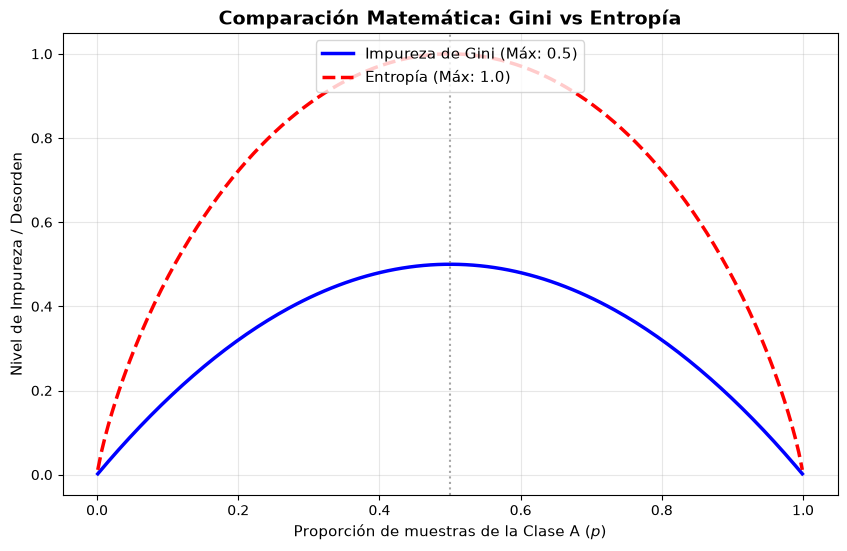

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir un rango de probabilidades de 0 a 1 (con pasos muy finos)
p = np.linspace(0.001, 0.999, 200)

# Fórmulas de impureza para un caso binario (dos clases)
gini = 1 - (p**2 + (1 - p)**2)
entropy = - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(p, gini, "b-", linewidth=2.5, label="Impureza de Gini (Máx: 0.5)")
plt.plot(p, entropy, "r--", linewidth=2.5, label="Entropía (Máx: 1.0)")

plt.title("Comparación Matemática: Gini vs Entropía", fontsize=14, fontweight='bold')
plt.xlabel("Proporción de muestras de la Clase A ($p$)", fontsize=11)
plt.ylabel("Nivel de Impureza / Desorden", fontsize=11)
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7)
plt.legend(loc="upper center", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(r"C:\Users\marco\Downloads\gini_vs_entropy.png", dpi=300) 
plt.show()


# Script 2: Prueba de Velocidad y Estructura (Demostración Práctica)

Este script genera un conjunto de datos grande y sintético para demostrar dos cosas:

1. La diferencia real en tiempos de entrenamiento ($O(n \times m \log_2(m))$).
2. Cómo el hiperparámetro `max_features` reduce drásticamente el tiempo de cómputo sacrificando un poco de control (ideal para bosques aleatorios).



In [ ]:
import time
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

# 1. Crear un dataset grande simulado (100,000 muestras, 40 características)
X_large, y_large = make_classification(n_samples=100_000, n_features=40, random_state=42)

# --- EXPERIMENTO 1: Gini vs Entropía ---
start_time = time.time()
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_large, y_large)
time_gini = time.time() - start_time

start_time = time.time()
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_large, y_large)
time_entropy = time.time() - start_time

# --- EXPERIMENTO 2: Acelerando el entrenamiento con max_features ---
start_time = time.time()
# Al usar "sqrt", el algoritmo solo evalúa la raíz cuadrada de las características en cada nodo en lugar de todas
clf_fast = DecisionTreeClassifier(criterion="gini", max_features="sqrt", random_state=42)
clf_fast.fit(X_large, y_large)
time_fast = time.time() - start_time

print("===== RESULTADOS DE COMPLEJIDAD Y RENDIMIENTO =====")
print(f"Tiempo usando Gini:       {time_gini:.4f} segundos")
print(f"Tiempo usando Entropía:   {time_entropy:.4f} segundos (Suele ser mayor debido a los logaritmos)")
print(f"Tiempo usando Gini + max_features='sqrt': {time_fast:.4f} segundos (¡Mucho más rápido!)")

print(f"\nProfundidad final del árbol Gini: {clf_gini.get_depth()}")
print(f"Profundidad final del árbol Entropía: {clf_entropy.get_depth()}")


===== RESULTADOS DE COMPLEJIDAD Y RENDIMIENTO =====
Tiempo usando Gini:       33.5066 segundos
Tiempo usando Entropía:   28.9736 segundos (Suele ser mayor debido a los logaritmos)
Tiempo usando Gini + max_features='sqrt': 3.9315 segundos (¡Mucho más rápido!)

Profundidad final del árbol Gini: 47
Profundidad final del árbol Entropía: 43
